# 2.1

#### 1. Сформировать идеальные частотные характеристики КИХ-фильтра, согласно параметрам по варианту. Количество отсчетов взять достаточно большим (N > 1000).

Np0: 300
Np1: 500
Ns0: 230
Ns1: 570


/tmp/ipykernel_1027126/1027080220.py:71: RuntimeWarning: divide by zero encountered in log10
  plt.plot(ff, 20*np.log10(x))
/tmp/ipykernel_1027126/1027080220.py:71: RuntimeWarning: invalid value encountered in log10
  plt.plot(ff, 20*np.log10(x))


Text(0, 0.5, 'Амплитуда[дБ]')

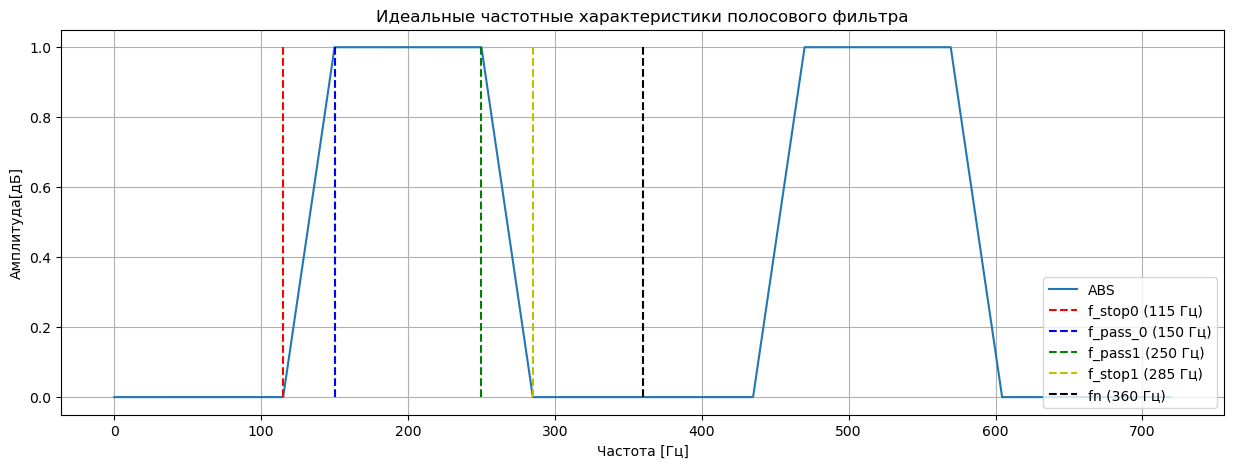

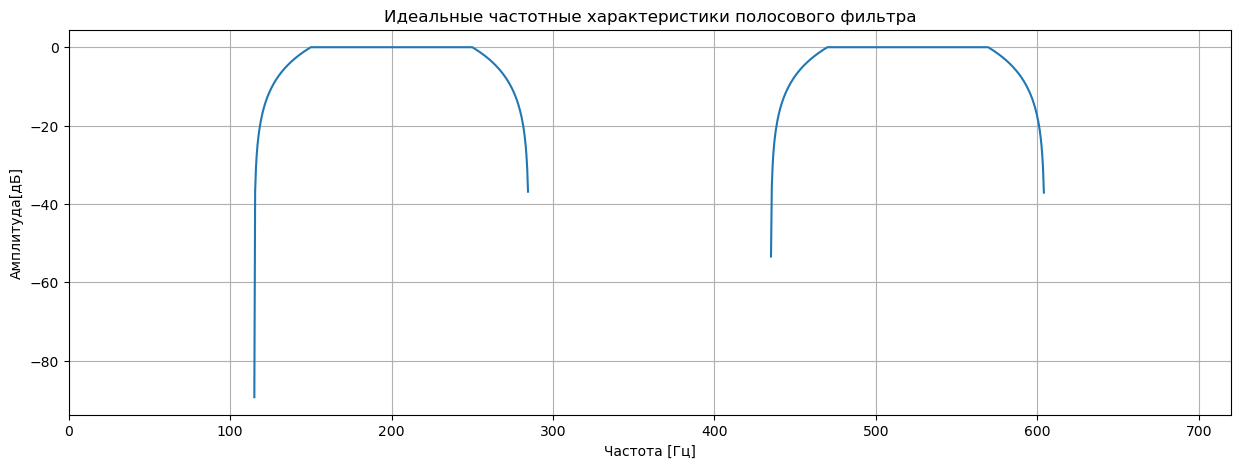

In [209]:
import numpy as np
import math
import matplotlib.pyplot as plt
from scipy.signal import lfilter, firwin2, freqz
from scipy.fftpack import fft, fftfreq, ifft

fo = 200
fs = 720
fn = int(fs / 2)
Nf = 20 + 1
Fpass = 100
Fstop = 170
N     = 1440

ff = np.linspace(0, fs, N, endpoint=False)
nn = np.linspace(0, N,  N, endpoint=False)
x = np.ones(N)

Np0 = int((fo-Fpass/2) * N /fs)
Ns0 = int((fo-Fstop/2) * N / fs)

Np1 = int((fo+Fpass/2) * N /fs)
Ns1 = int((fo+Fstop/2) * N / fs)

print(f'Np0: {Np0}')
print(f'Np1: {Np1}')
print(f'Ns0: {Ns0}')
print(f'Ns1: {Ns1}')

x[0    :Ns0  ] = 0
x[Ns1  :N-Ns1] = 0
x[N-Ns0:N    ] = 0

k0 = np.arctan(1/(Np0-Ns0))
b0 = (1 - k0 *(Np0+Ns0))/2

k1 = np.arctan(1/(Np1-Ns1))
b1 = (1 - k1 *(Np1+Ns1))/2

# ========================================
for i in range(Ns0, Np0):
  x[i] = ((k0 * (i))+b0)
for i in range(Np1, Ns1):
  x[i] = ((k1 * (i)) + b1)

# ========================================
for i in range(N - Np0, N - Ns0):
  x[i] = (k1 * (i) + 2.121 * b1)
for i in range(N - Ns1, N - Np1):
  x[i] = (k0 * (i) + 3.782 * b0)


plt.figure(figsize=[15,5])
plt.plot(ff, x)
plt.title('Идеальные частотные характеристики полосового фильтра')
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда[дБ]')
plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')

plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')

plt.plot([fn,fn], [0,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')
plt.grid(True)

plt.figure(figsize=[15,5])
plt.title('Идеальные частотные характеристики полосового фильтра')
plt.plot(ff, 20*np.log10(x))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда[дБ]')

#### 2. Получить идеальную импульсную характеристику фильтра, применив ОБПФ к идеальной частотной характеристике фильтра.

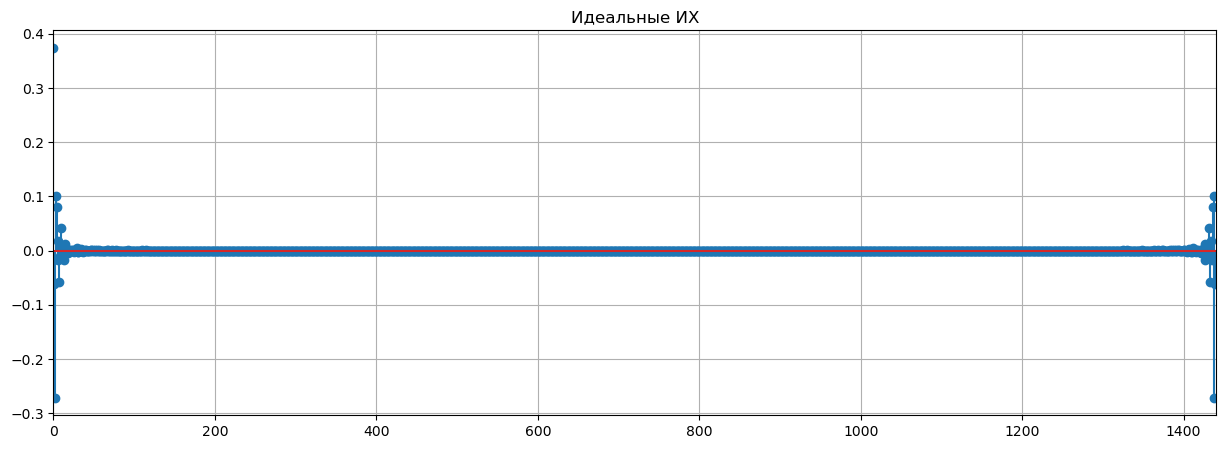

In [210]:
y = np.real(ifft(x))

plt.figure(figsize=[15,5])
plt.title('Идеальные ИХ')
plt.stem(nn, y)
plt.xlim([0, N])
plt.grid(True)

#### 3. Сделать "усечение" идеальной импульсной характеристики до размера, равного порядку фильтра + 1. Это необходимо сделать таким образом, чтобы в импульсной характеристике остались значимые отсчеты: нулевой отсчет, order/2 отсчетов из отрицательной области и order/2 отсчетов из положительной области (подобно тому, как мы это делали в лабораторной работе №2 в задании с комплексной гармонической вырезкой).

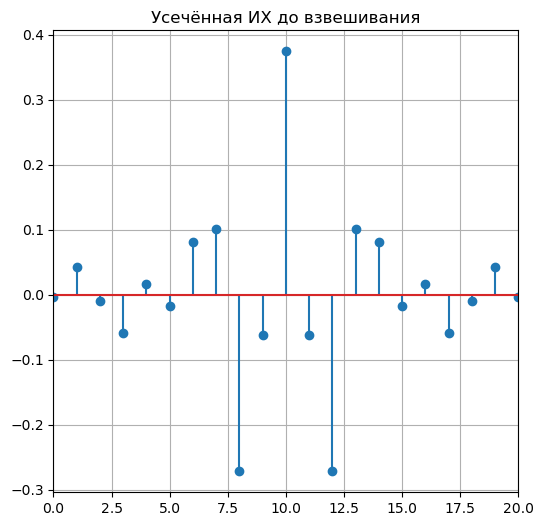

In [211]:
nf = np.linspace(0, Nf,  Nf, endpoint=False)
y1 = np.zeros(Nf)
y1[0:int(Nf /2)] = y[N-int(Nf/2):N]
y1[int(Nf /2):Nf] = y[0:int(np.ceil(Nf/2))]
plt.figure(figsize=[6,6])
plt.title('Усечённая ИХ до взвешивания')
plt.stem(nf, y1)
plt.xlim([0, Nf-1])
plt.grid(True)

#### 4. Построить частотные характеристики фильтра, соответствующие усеченной импульсной характеристике.

Text(0, 0.5, 'Амплитуда[дБ]')

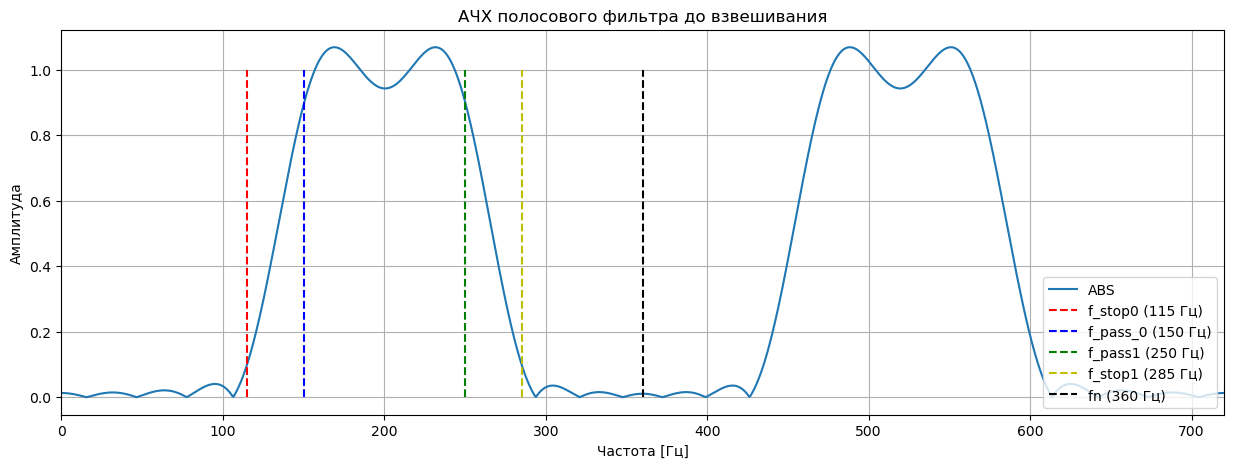

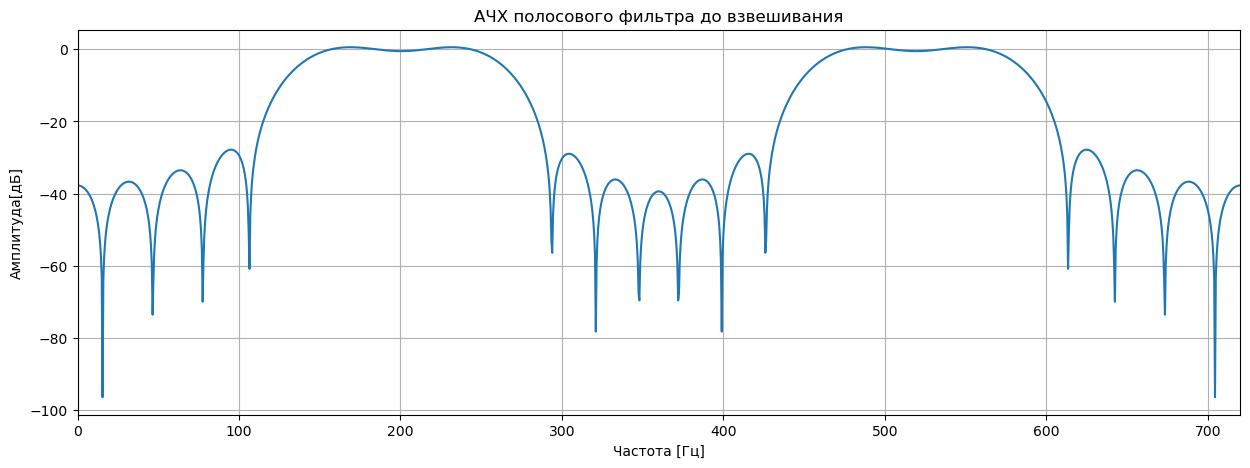

In [212]:
w, h = freqz(y1, worN=N, fs=fs, whole=True)

plt.figure(figsize=[15,5])
plt.title('АЧХ полосового фильтра до взвешивания')
plt.plot(w, abs(h))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда')
plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')

plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')

plt.plot([fn,fn], [0,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')


plt.figure(figsize=[15,5])
plt.title('АЧХ полосового фильтра до взвешивания')
plt.plot(w, 20*np.log10(h))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда[дБ]')

#### 5. Применить оконную функцию к импульсной характеристике (взвешивание). Для этого усеченную импульсную характеристику необходимо поэлементно умножить на массив соответствующей оконной функции нужного размера. Изобразить на графике усеченную импульсную характеристику фильтра до и после взвешивания, а также саму оконную функцию.
#### 6. Построить частотные характеристики фильтра, соответствующие усеченной взыешенной импульсной характеристике. Проанализировать результаты и сделать выводы

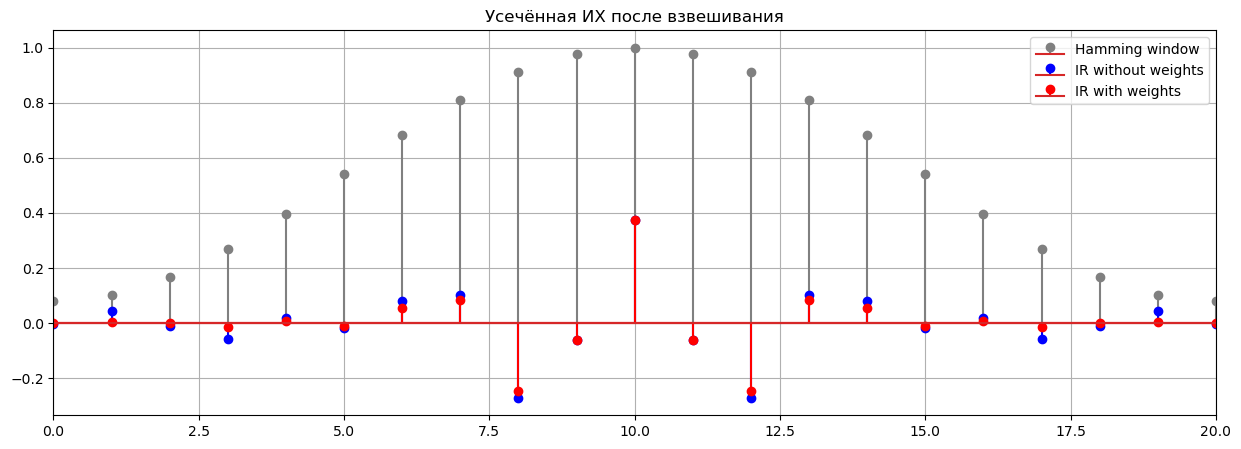

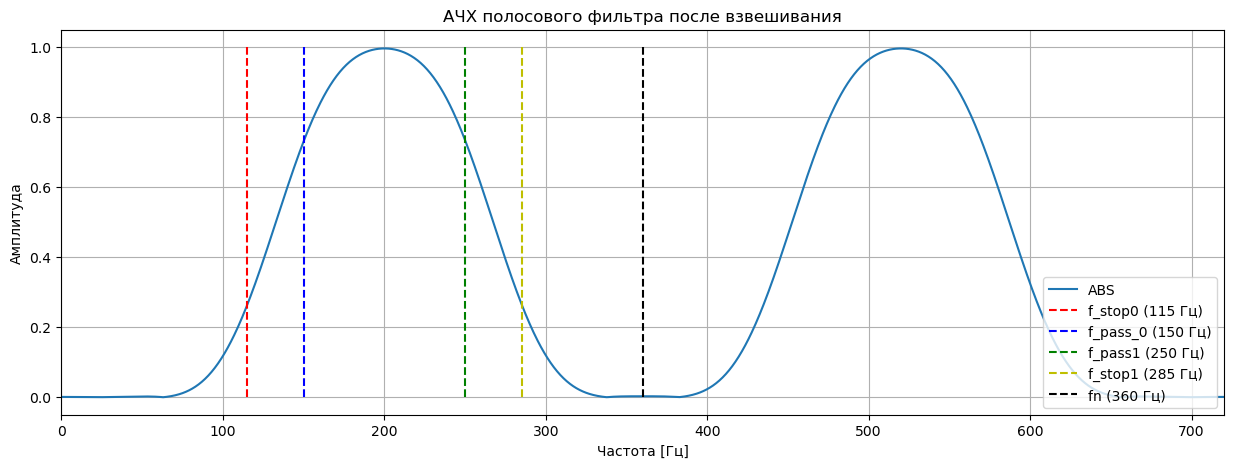

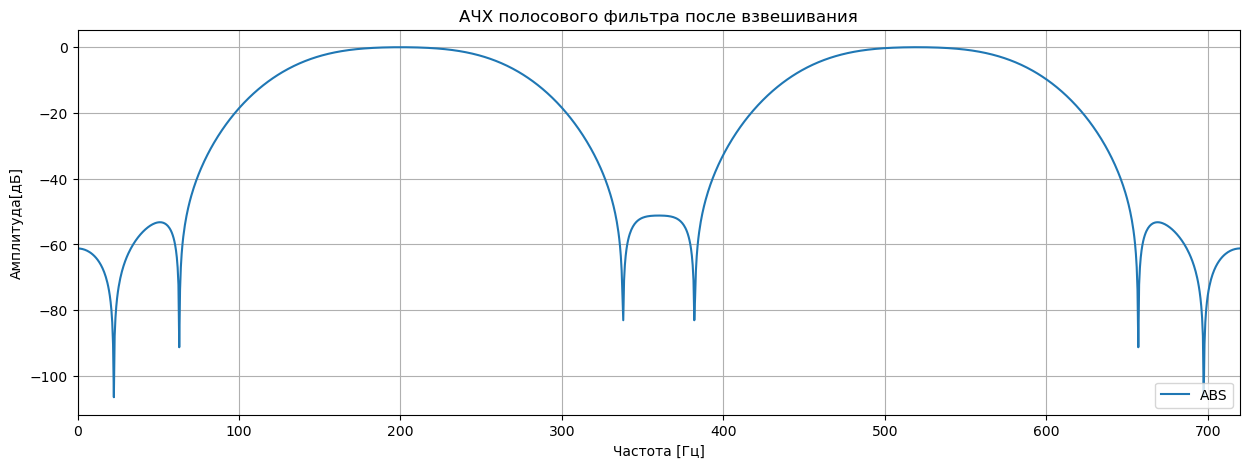

In [213]:
Window = 0.54 - 0.46 * np.cos((2 * np.pi * nf)/(Nf - 1))
# plt.figure(figsize=[6,6])
# plt.title('Окно Хеминга')
# plt.stem(nf, Window)
# plt.xlim([0, Nf - 1])
# plt.grid(True)
# plt.xlabel('n')
# plt.ylabel('w(n)')

y2 = y1 * Window

plt.figure(figsize=[15,5])
plt.title('Усечённая ИХ после взвешивания')
plt.stem(nf, Window, 'gray', label='Hamming window')
plt.stem(nf, y1, 'blue', label='IR without weights')
plt.stem(nf, y2, 'red', label='IR with weights')
plt.legend()
plt.xlim([0, Nf - 1])
plt.grid(True)

w1, h1 = freqz(y2, worN=N, fs=fs, whole=True)

plt.figure(figsize=[15,5])
plt.title('АЧХ полосового фильтра после взвешивания')
plt.plot(w1, abs(h1))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда')

plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')
plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')
plt.plot([fn,fn], [0,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')

plt.figure(figsize=[15,5])
plt.title('АЧХ полосового фильтра после взвешивания')
plt.plot(w1, 20*np.log10(h1))
plt.xlim([0, fs]) 
plt.grid(True)
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда[дБ]')
# plt.plot([fo-Fstop/2, fo-Fstop/2], [-100,1], 'r--')
# plt.plot([fo-Fpass/2, fo-Fpass/2], [-100,1], 'b--')
# plt.plot([fo+Fpass/2, fo+Fpass/2], [-100,1], 'g--')
# plt.plot([fo+Fstop/2, fo+Fstop/2], [-100,1], 'y--')
# plt.plot([fn,fn], [-100,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')

#### 7. Изучить возможности пакета scipy.signal.firwin2 для задачи синтеза КИХ-фильтра оконным методом. Синтезировать фильтр, используя функцию firwin2.
#### 8. Убедиться в идентичности результатов, полученных на этапах 6 и 7

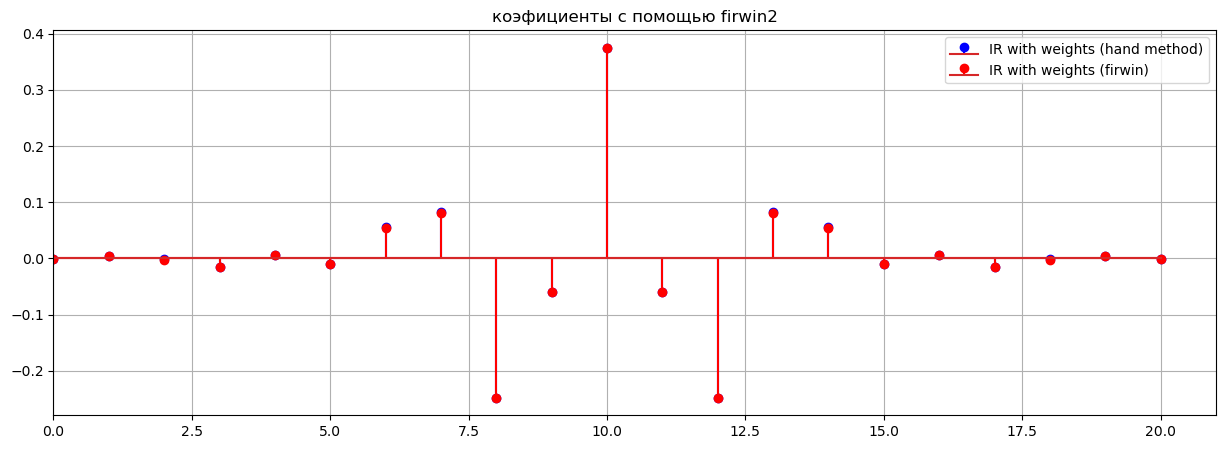

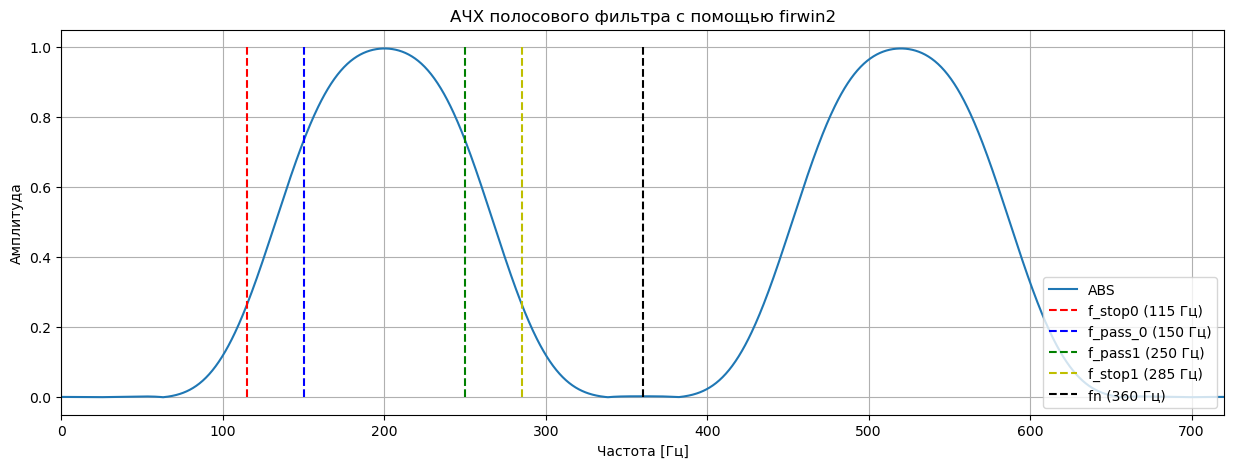

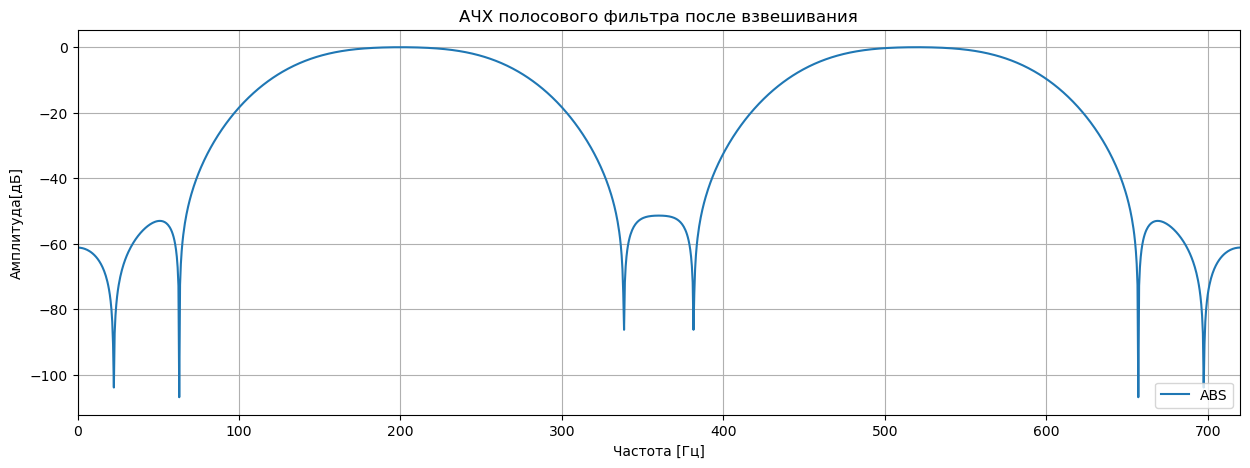

In [214]:
import numpy as np
from scipy.signal import firwin2, freqz, windows
import matplotlib.pyplot as plt


filter_coefs = firwin2(Nf, [0.0,Ns0/2, Np0/2, Np1/2, Ns1/2, fn], [0.0, 0.0, 1.0, 1.0,0.0,0.0],fs=fs, window='hamming')
# Анализ характеристик фильтра
w3, h3 = freqz(filter_coefs, worN=N, fs=fs, whole=True)

plt.figure(figsize=[15,5])
plt.title('коэфициенты с помощью firwin2')
plt.stem(nf, y2, 'blue', label='IR with weights (hand method)')
plt.stem(nf, filter_coefs, 'red', label='IR with weights (firwin)')
plt.legend()
plt.xlim([0, Nf])
plt.grid(True)

plt.figure(figsize=[15,5])
plt.title('АЧХ полосового фильтра с помощью firwin2')
plt.plot(w3, abs(h3))
plt.xlim([0, fs]) 
plt.grid(True)
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда')
plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')
plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')
plt.plot([fn,fn], [0,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')


plt.figure(figsize=[15,5])
plt.title('АЧХ полосового фильтра после взвешивания')
plt.plot(w3, 20*np.log10(h3))
plt.xlim([0, fs]) 
plt.grid(True)
plt.xlabel('Частота [Гц]')
plt.ylabel('Амплитуда[дБ]')
# plt.plot([fo-Fstop/2, fo-Fstop/2], [-100,1], 'r--')
# plt.plot([fo-Fpass/2, fo-Fpass/2], [-100,1], 'b--')
# plt.plot([fo+Fpass/2, fo+Fpass/2], [-100,1], 'g--')
# plt.plot([fo+Fstop/2, fo+Fstop/2], [-100,1], 'y--')
# plt.plot([fn,fn], [-100,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)', 
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')


# 2.2

#### 1. Сформировать сигнал, состоящий из двух гармоник разных амплитуд, как мы это делали в лабораторной работе №2. При этом, одна гармоника должна быть из области частот пропускания вашего КИХ-фильтра, а вторая - из области частот запирания.

In [215]:
Amp1 = 2
Amp2 = 1

f1 = 200
f2 = 359

T = 1/fs

t = np.linspace(0, N*T, N, endpoint = False)

x1 = Amp1 * np.cos(2 * np.pi * f1 * t)
x2 = Amp2 * np.cos(2 * np.pi * f2 * t)

xsum = x1 + x2
dff = fft(xsum) / N

#### 2. Применить разработанный фильтр к сигналу во временной области (исользуя свертку, np.convolve())

In [216]:

xsum_fil = np.convolve(y2, xsum[0:N - Nf + 1])
print(len(xsum_fil))
print(len(y2))
print(len(xsum[0:N - Nf + 1]))
dff_fil = fft(xsum_fil) / N

1440
21
1420


#### 3. Построить графики сигнала во временной и в частотной областях до и после применения фильтра. Проанализировать результаты и сделать выводы

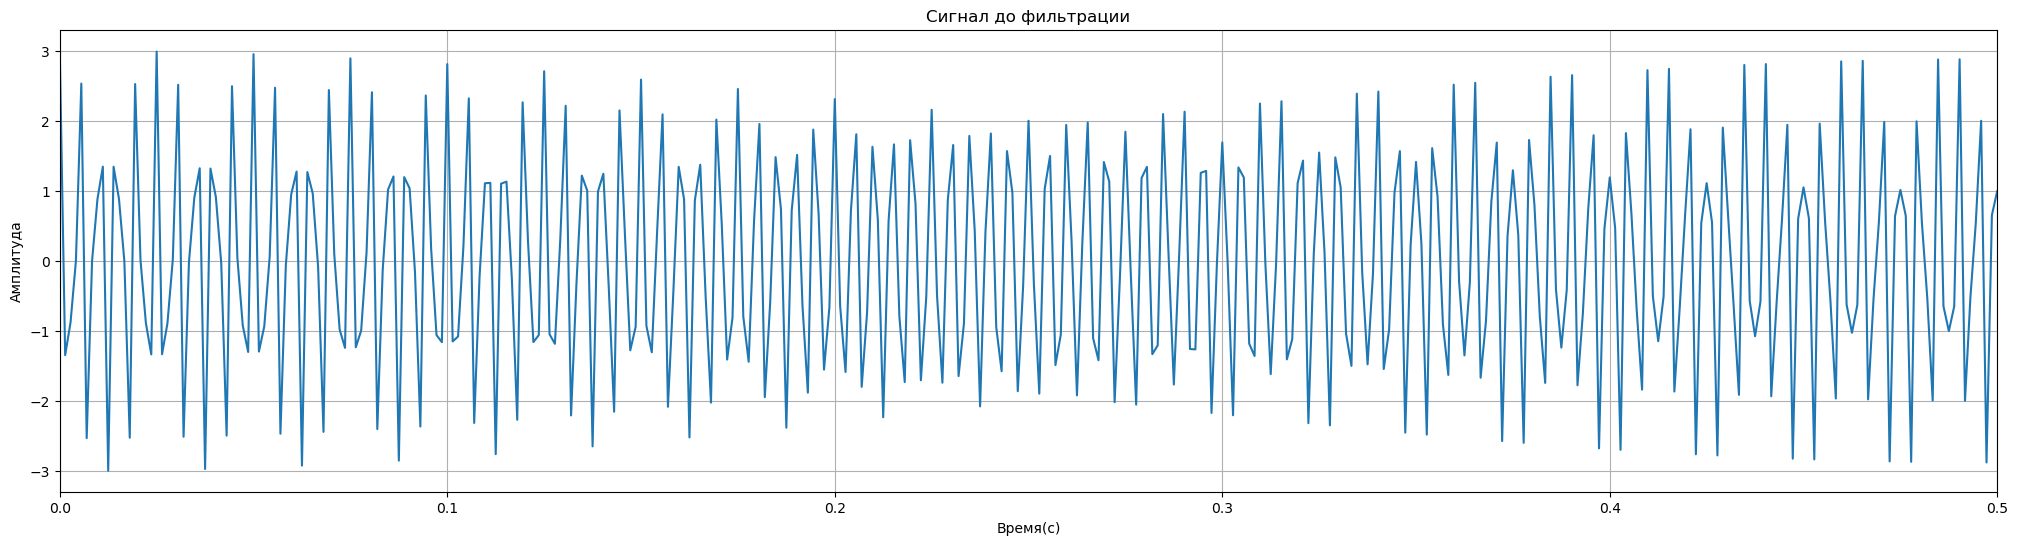

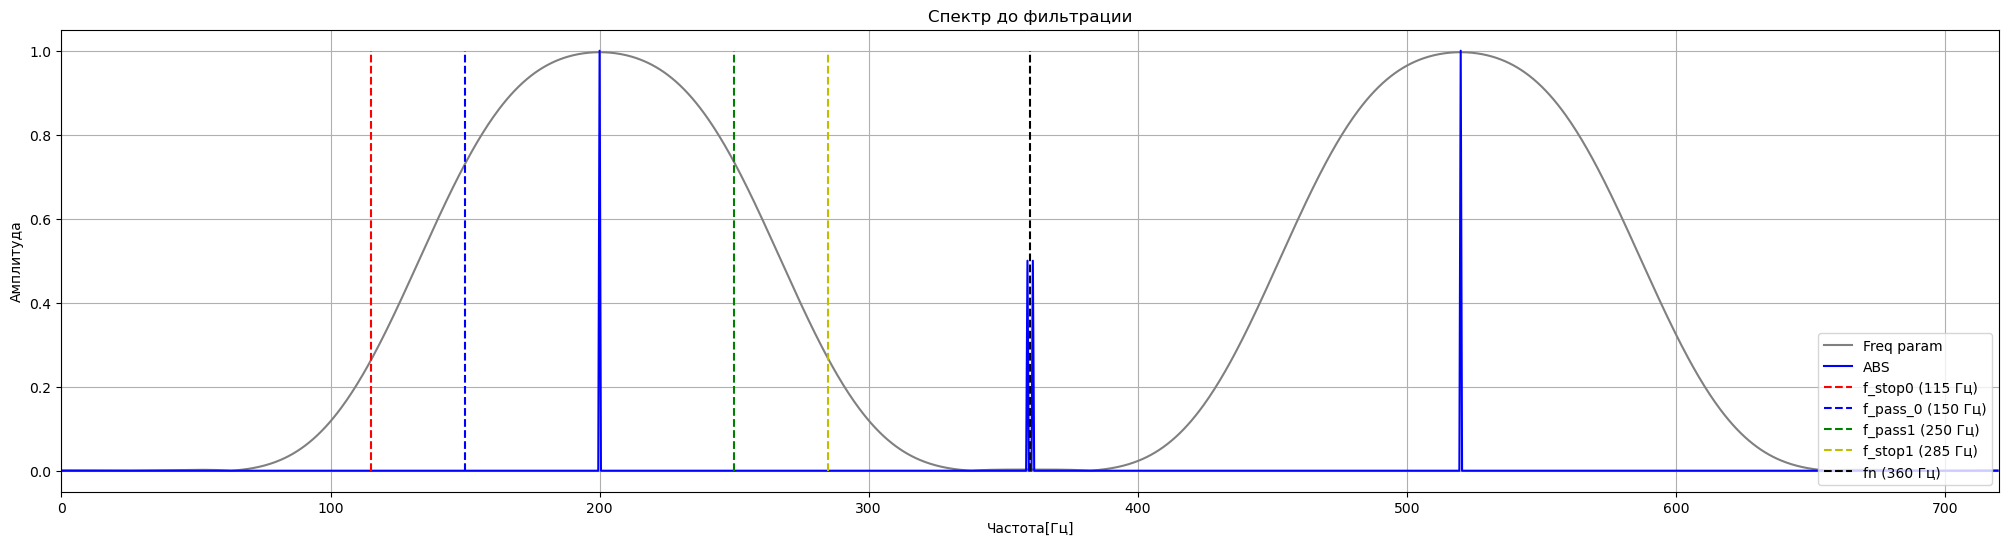

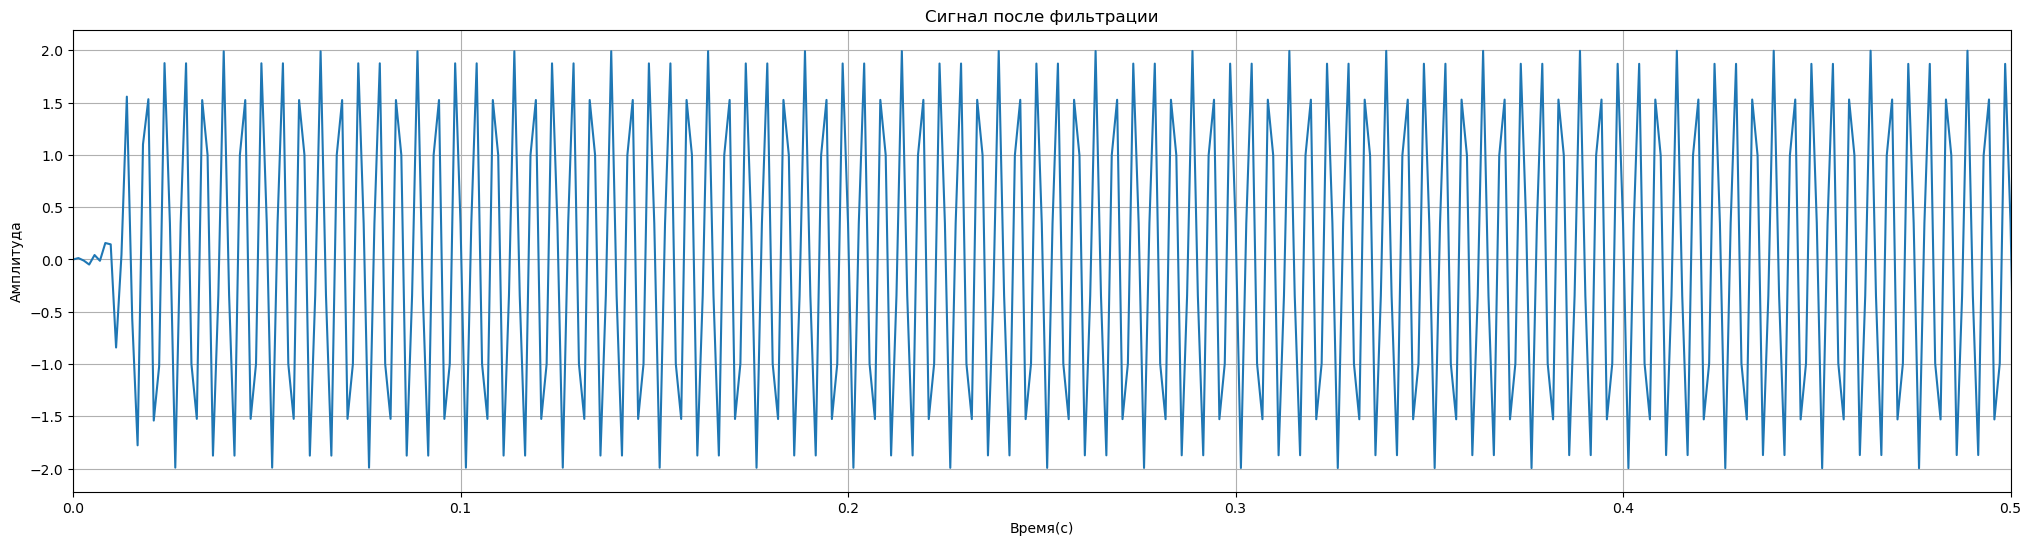

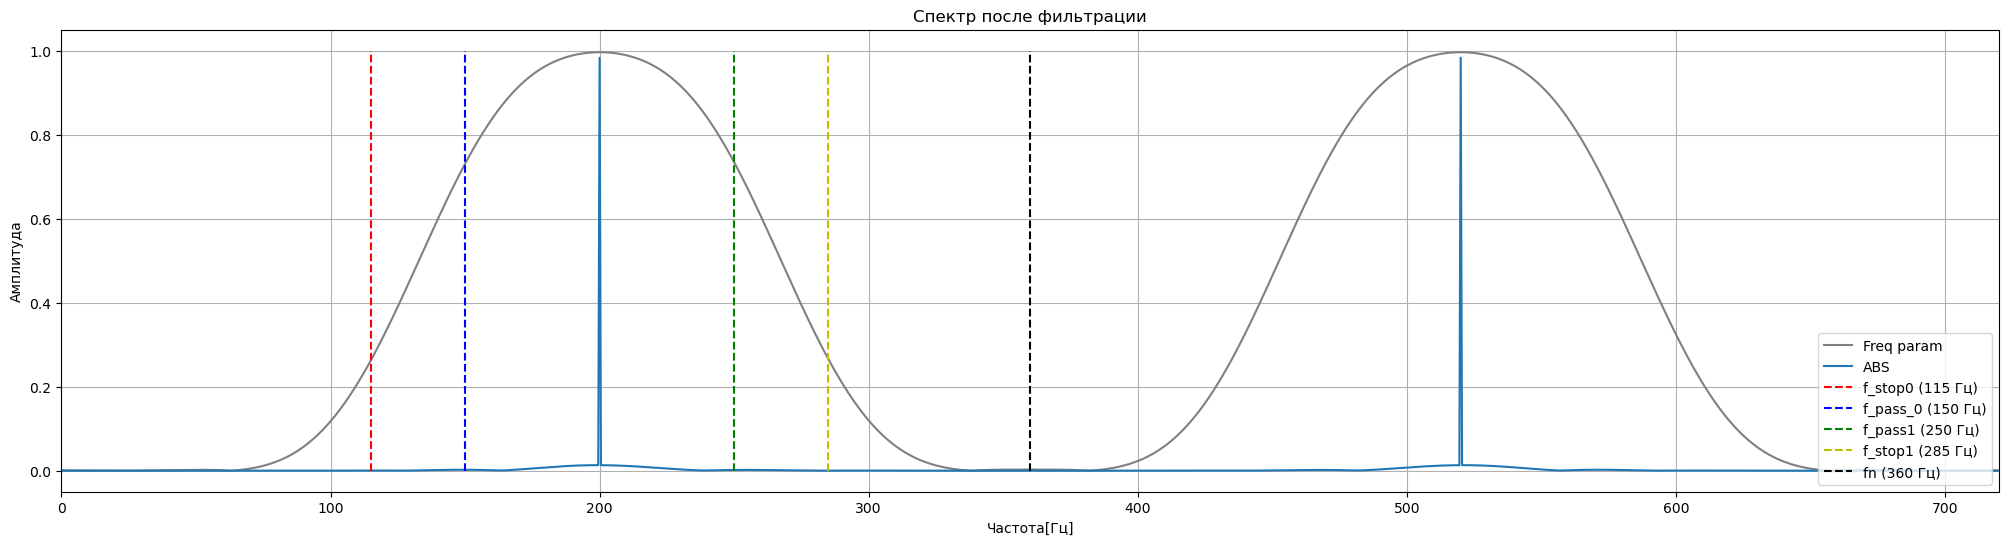

In [217]:
plt.figure(figsize=[25,6])
plt.title('Сигнал до фильтрации')
plt.plot(t, xsum)
plt.xlim([0, N*T/4])
plt.grid(True)
plt.xlabel('Время(с)')
plt.ylabel('Амплитуда')

plt.figure(figsize=[25,6])
plt.title('Спектр до фильтрации')
plt.plot(w1, abs(h1), 'gray', label='freq param')
plt.plot(ff, np.abs(dff), 'blue', label='signal spectrum')
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота[Гц]')
plt.ylabel('Амплитуда')
plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')
plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')
plt.plot([fn,fn], [0,1], 'k--')
plt.legend(['Freq param', 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')


plt.figure(figsize=[25,6])
plt.title('Сигнал после фильтрации')
plt.plot(t, xsum_fil)
plt.xlim([0, N*T/4])
plt.grid(True)
plt.xlabel('Время(с)')
plt.ylabel('Амплитуда')

plt.figure(figsize=[25,6])
plt.title('Спектр после фильтрации')
plt.plot(w1, abs(h1), 'gray', label='freq param')
plt.plot(ff, np.abs(dff_fil))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота[Гц]')
plt.ylabel('Амплитуда')

plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')
plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')
plt.plot([fn,fn], [0,1], 'k--')
plt.legend(['Freq param', 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')
plt.show()

# Доп Задание
### Написать функцию, реализующую алгоритм свертки. Добиться идентичности результатов с функцией np.convolve().

$$
y(k) = b*x = \sum_{i=0}^{m}b(i)\cdot x(k-i) \tag{3}.
$$ 

False


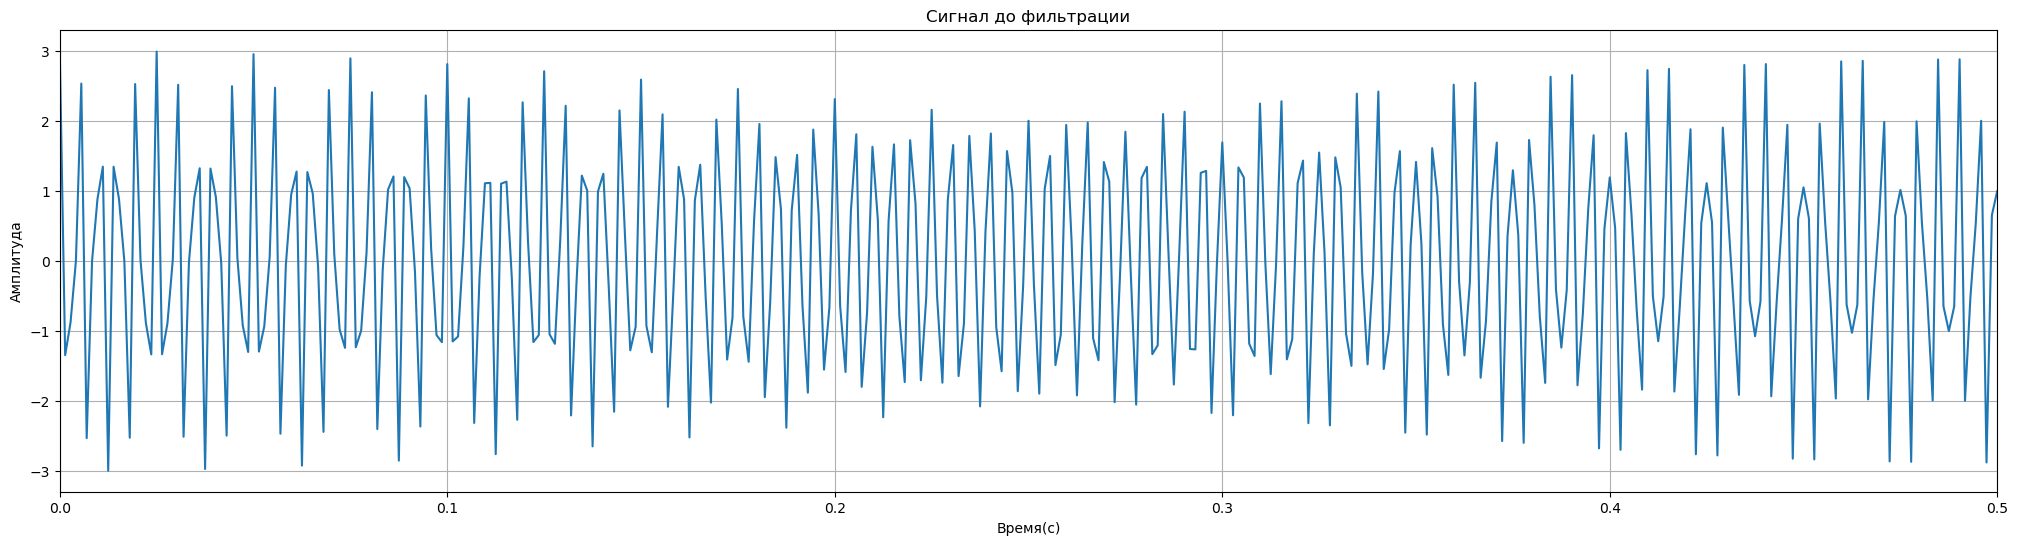

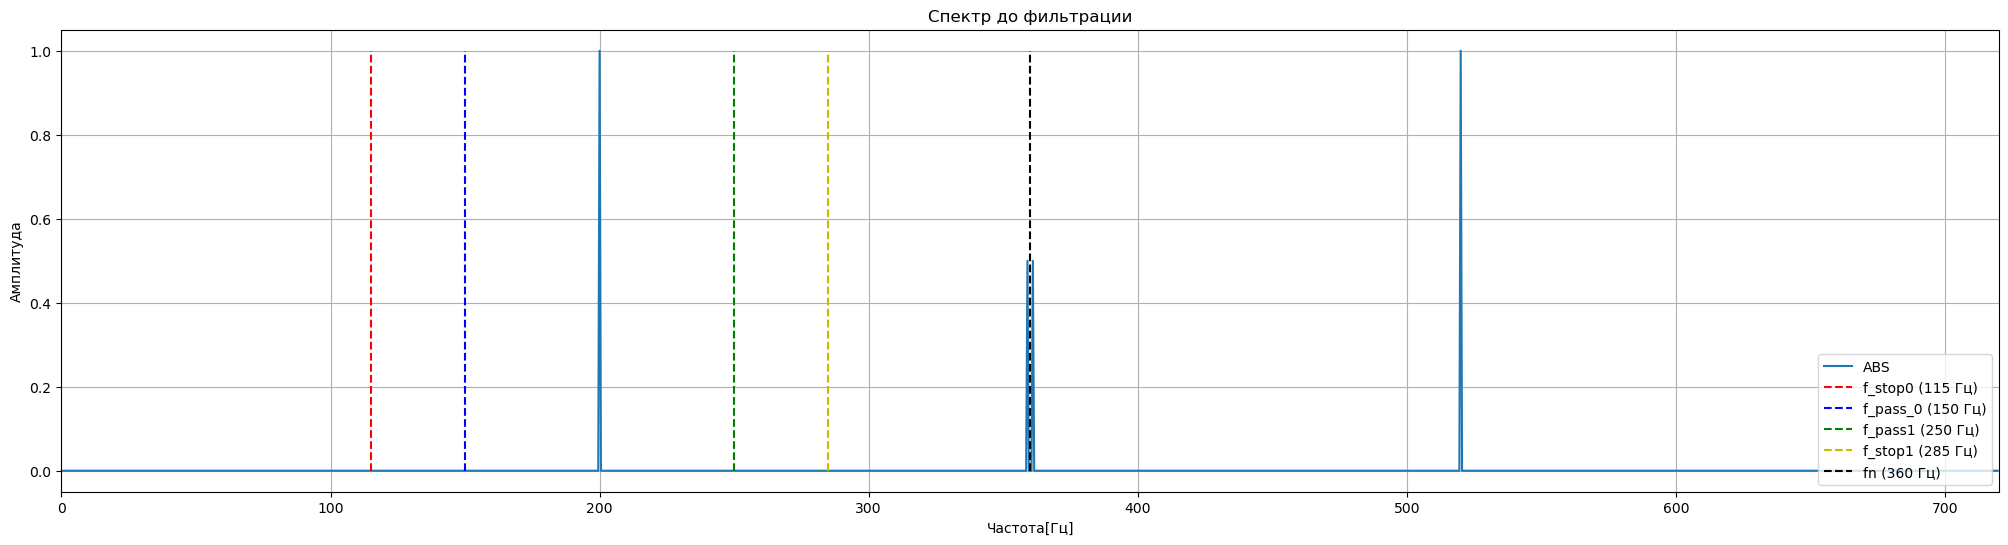

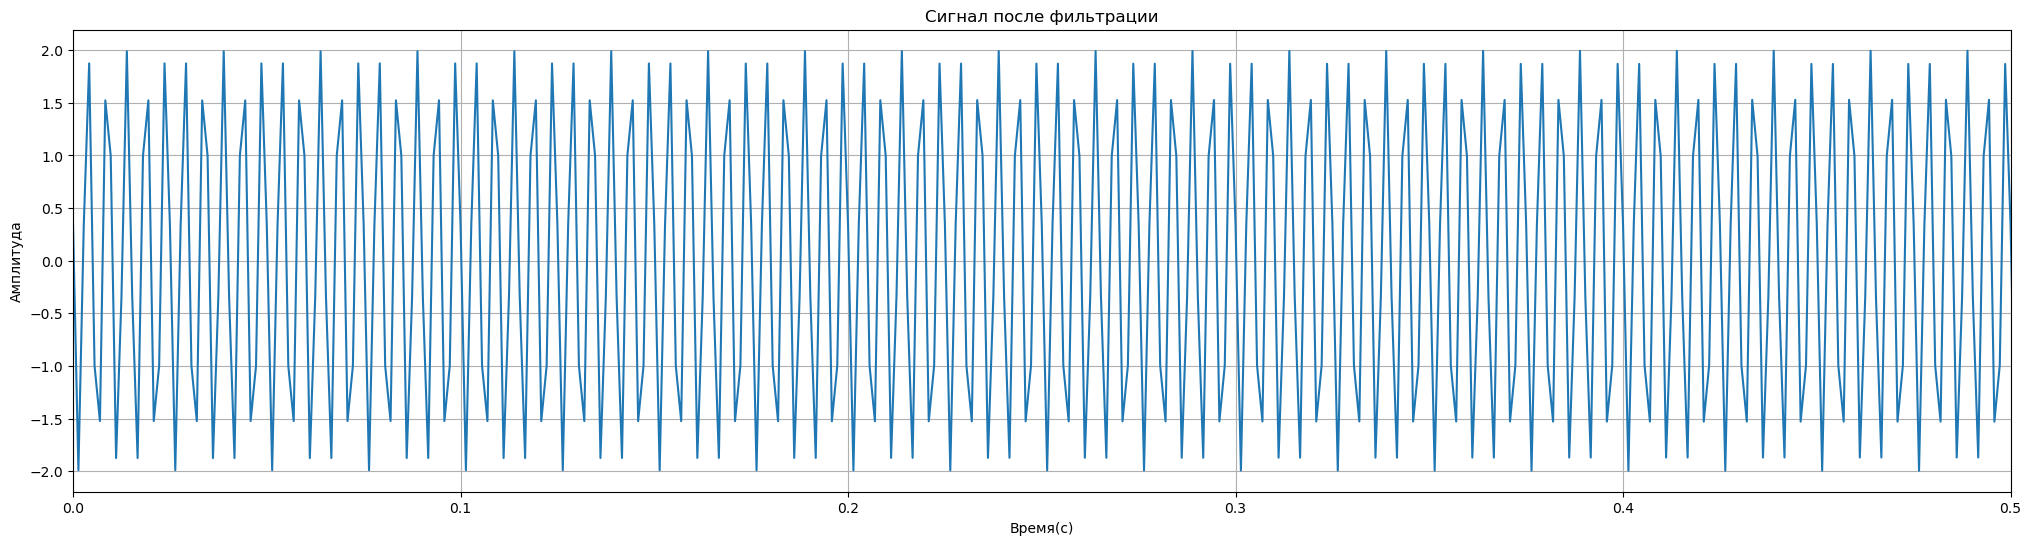

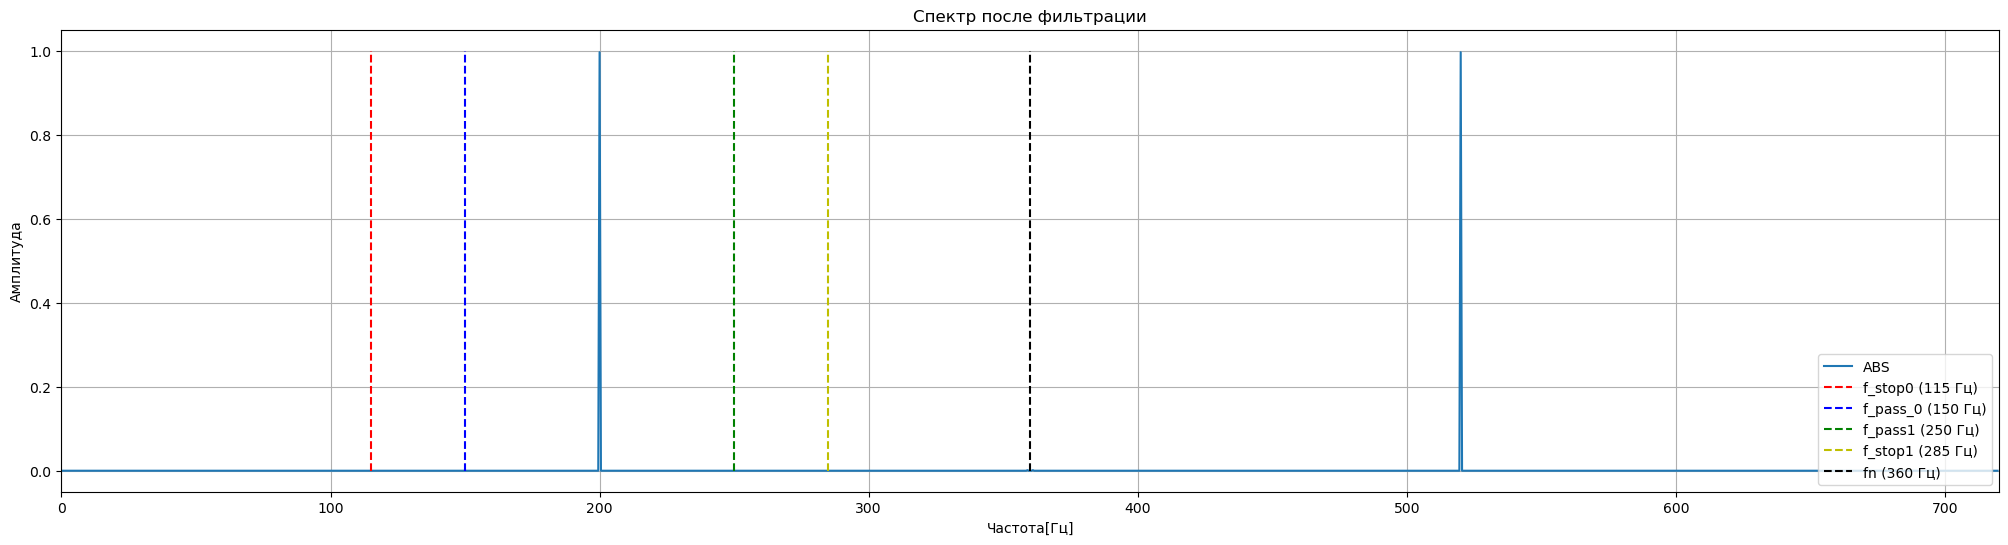

In [218]:
from scipy import fftpack

Amp1 = 2
Amp2 = 1

f1 = 200
f2 = 359

T = 1/fs

t = np.linspace(0, N*T, N, endpoint = False)

x1 = Amp1 * np.cos(2 * np.pi * f1 * t)
x2 = Amp2 * np.cos(2 * np.pi * f2 * t)

xsum = x1 + x2
dff = fft(xsum) / N

xsum_fil = np.convolve(y2, xsum[0:N - Nf + 1])

Y2 = np.zeros(N)

# Extended version of IR with window
Y2[0:Nf] = y2

# Convolving with formula
y = np.zeros(N)
Y_convolve = np.zeros(N)
for n in range(N):
    for m in range(N):
        Y_convolve[n] += Y2[m] * xsum[(n - m)]

plt.figure(figsize=[25,6])
plt.title('Сигнал до фильтрации')
plt.plot(t, xsum)
plt.xlim([0, N*T/4])
plt.grid(True)
plt.xlabel('Время(с)')
plt.ylabel('Амплитуда')


plt.figure(figsize=[25,6])
plt.title('Спектр до фильтрации')
plt.plot(ff, np.abs(dff))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота[Гц]')
plt.ylabel('Амплитуда')
plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')
plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')
plt.plot([fn,fn], [0,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)', 
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')

# Getting spectrum
dff_fil = fft(Y_convolve) / N
plt.figure(figsize=[25,6])
plt.title('Сигнал после фильтрации')
plt.plot(t, Y_convolve)
plt.xlim([0, N*T/4])
plt.grid(True)
plt.xlabel('Время(с)')
plt.ylabel('Амплитуда')


plt.figure(figsize=[25,6])
plt.title('Спектр после фильтрации')
plt.plot(ff, np.abs(dff_fil))
plt.xlim([0, fs])
plt.grid(True)
plt.xlabel('Частота[Гц]')
plt.ylabel('Амплитуда')

plt.plot([fo-Fstop/2, fo-Fstop/2], [0,1], 'r--')
plt.plot([fo-Fpass/2, fo-Fpass/2], [0,1], 'b--')
plt.plot([fo+Fpass/2, fo+Fpass/2], [0,1], 'g--')
plt.plot([fo+Fstop/2, fo+Fstop/2], [0,1], 'y--')
plt.plot([fn,fn], [0,1], 'k--')
plt.legend([ 'ABS', 'f_stop0 (115 Гц)', 'f_pass_0 (150 Гц)',
            'f_pass1 (250 Гц)', 'f_stop1 (285 Гц)','fn (360 Гц)'], loc='lower right')
plt.show()